In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
import kagglehub


In [ ]:
path = kagglehub.dataset_download("adelanseur/taxi-trips-chicago-2024")
print(path)

Using Colab cache for faster access to the 'taxi-trips-chicago-2024' dataset.
/kaggle/input/taxi-trips-chicago-2024


In [ ]:
import os
print(os.listdir(path))

['Taxi_Trips_-_2024_20240408.csv']


In [ ]:
data = pd.read_csv(path + "/Taxi_Trips_-_2024_20240408.csv")
data = data[['Trip Miles', 'Trip Total']]
print(data.shape)
data.head()

(865247, 2)


,Trip Miles,Trip Total
0,0.09,38.75
1,3.00,12.00
2,5.84,26.70
3,13.36,47.10
4,6.13,22.82


In [ ]:
data.dropna(inplace=True)
print(data.shape)
data.isnull().sum()

(863196, 2)


,0
Trip Miles,0
Trip Total,0


In [ ]:
def remove_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return df[(df[column] >= lower) & (df[column] <= upper)]

data = remove_outliers(data, 'Trip Miles')
data = remove_outliers(data, 'Trip Total')
print(data.shape)

(846790, 2)


In [ ]:
x = data.iloc[:, :1].values
y = data.iloc[:, 1:2].values

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [ ]:
model = LinearRegression()
model.fit(x_train, y_train)

print("Coefficient:", model.coef_)
print("Intercept:", model.intercept_)

Coefficient: [[2.47145839]]
Intercept: [10.02421236]


In [ ]:
y_pred = model.predict(x_test)
r2 = r2_score(y_test, y_pred)
print("R² Score:", r2)

R² Score: 0.6885674900078107


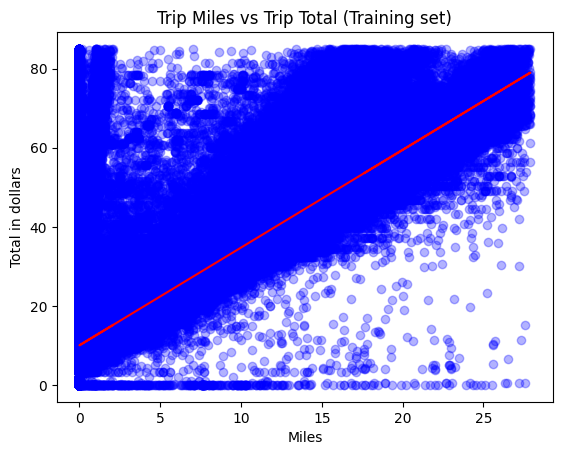

In [ ]:
plt.scatter(x_train, y_train, color='blue', alpha=0.3)
plt.plot(x_train, model.predict(x_train), color='red')
plt.title('Trip Miles vs Trip Total (Training set)')
plt.xlabel('Miles')
plt.ylabel('Total in dollars')
plt.show()

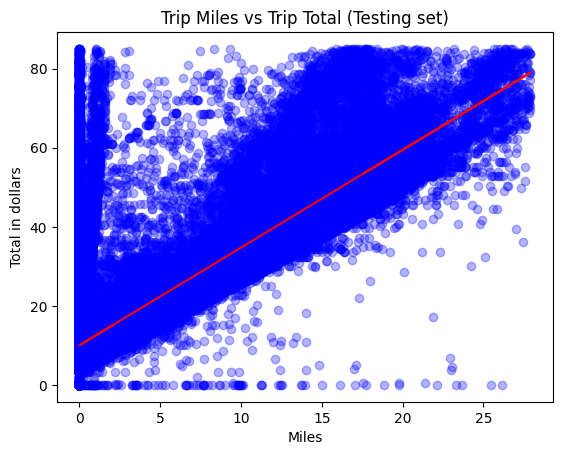

In [ ]:
plt.scatter(x_test, y_test, color='blue', alpha=0.3)
plt.plot(x_train, model.predict(x_train), color='red')
plt.title('Trip Miles vs Trip Total (Testing set)')
plt.xlabel('Miles')
plt.ylabel('Total in dollars')
plt.show()